In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Load dataset
file_path = "stroke_dataset_smote.csv"
df = pd.read_csv(file_path)

# Show first 5 rows
print(df.head())

   Age  Hypertension  Heart_Disease  Average_Glucose_Level    BMI  \
0   69             0              0                 153.40  17.93   
1   32             0              1                 158.33  40.75   
2   89             0              0                  73.54  16.81   
3   78             0              0                 290.89  29.79   
4   38             0              0                  91.85  49.86   

   Physical_Activity  Alcohol_Intake  Stress_Level  Blood_Pressure  \
0                 38               8          6.62             195   
1                101               0          1.38              93   
2                 43               3          2.34             133   
3                 92               2          6.13             199   
4                119               7          2.57             103   

   Cholesterol  ...  Work_Type_Govt_job  Work_Type_Never_worked  \
0          158  ...               False                    True   
1          232  ...           

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73698 entries, 0 to 73697
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      73698 non-null  int64  
 1   Hypertension             73698 non-null  int64  
 2   Heart_Disease            73698 non-null  int64  
 3   Average_Glucose_Level    73698 non-null  float64
 4   BMI                      73698 non-null  float64
 5   Physical_Activity        73698 non-null  int64  
 6   Alcohol_Intake           73698 non-null  int64  
 7   Stress_Level             73698 non-null  float64
 8   Blood_Pressure           73698 non-null  int64  
 9   Cholesterol              73698 non-null  int64  
 10  MRI_Result               73698 non-null  float64
 11  Sex_Male                 73698 non-null  bool   
 12  Ever_Married_Yes         73698 non-null  bool   
 13  Work_Type_Govt_job       73698 non-null  bool   
 14  Work_Type_Never_worked

In [ ]:
df.describe()

,Age,Hypertension,Heart_Disease,Average_Glucose_Level,BMI,Physical_Activity,Alcohol_Intake,Stress_Level,Blood_Pressure,Cholesterol,MRI_Result,Stroke
count,73698.000000,73698.000000,73698.000000,73698.000000,73698.000000,73698.000000,73698.000000,73698.000000,73698.000000,73698.000000,73698.000000,73698.000000
mean,56.458479,0.090694,0.058618,185.056968,32.483709,90.485875,6.768365,5.012617,145.174130,200.179164,50.316529,0.500000
std,21.828357,0.287176,0.234909,66.514535,9.486335,52.103196,4.024500,2.660015,31.459315,57.677660,28.260635,0.500003
min,18.000000,0.000000,0.000000,70.000000,15.000000,0.000000,0.000000,0.000000,90.000000,100.000000,0.000000,0.000000
25%,38.000000,0.000000,0.000000,126.680000,24.513404,45.000000,3.000000,2.831973,118.000000,150.000000,25.990000,0.000000
50%,56.000000,0.000000,0.000000,185.885000,32.480000,91.000000,7.000000,5.024794,145.000000,200.000000,50.240000,0.500000
75%,75.000000,0.000000,0.000000,242.462097,40.410220,136.000000,10.000000,7.196879,173.000000,250.000000,75.020000,1.000000
max,95.000000,1.000000,1.000000,299.990000,50.000000,180.000000,14.000000,10.000000,200.000000,300.000000,100.000000,1.000000


In [ ]:
df.shape

(73698, 23)

In [ ]:
target_temp=df.Stroke.value_counts()
print(target_temp)

Stroke
0    36849
1    36849
Name: count, dtype: int64


In [ ]:
print("Percentage of patience without heart problems: "+str(round(target_temp[0]*100/41000,2)))
print("Percentage of patience with heart problems: "+str(round(target_temp[1]*100/41000,2)))

Percentage of patience without heart problems: 89.88
Percentage of patience with heart problems: 89.88


In [ ]:
# Features (X)
X = df.drop("Stroke", axis=1)

# Target (y)
y = df["Stroke"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Logistic Regression Accuracy: 0.8061736770691995
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      7377
           1       0.81      0.80      0.80      7363

    accuracy                           0.81     14740
   macro avg       0.81      0.81      0.81     14740
weighted avg       0.81      0.81      0.81     14740



In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Decision Tree Accuracy: 0.8240841248303935
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      7377
           1       0.81      0.85      0.83      7363

    accuracy                           0.82     14740
   macro avg       0.83      0.82      0.82     14740
weighted avg       0.83      0.82      0.82     14740



In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Random Forest Accuracy: 0.9101763907734057
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      7377
           1       0.95      0.86      0.91      7363

    accuracy                           0.91     14740
   macro avg       0.91      0.91      0.91     14740
weighted avg       0.91      0.91      0.91     14740



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

KNN Accuracy: 0.8591587516960651
              precision    recall  f1-score   support

           0       0.89      0.82      0.85      7377
           1       0.84      0.89      0.86      7363

    accuracy                           0.86     14740
   macro avg       0.86      0.86      0.86     14740
weighted avg       0.86      0.86      0.86     14740



In [ ]:
from sklearn.svm import SVC

model = SVC(kernel='rbf')

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

SVM Accuracy: 0.8497286295793759
              precision    recall  f1-score   support

           0       0.79      0.94      0.86      7377
           1       0.93      0.75      0.83      7363

    accuracy                           0.85     14740
   macro avg       0.86      0.85      0.85     14740
weighted avg       0.86      0.85      0.85     14740



In [ ]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Naive Bayes Accuracy: 0.7254409769335143
              precision    recall  f1-score   support

           0       0.83      0.57      0.67      7377
           1       0.67      0.89      0.76      7363

    accuracy                           0.73     14740
   macro avg       0.75      0.73      0.72     14740
weighted avg       0.75      0.73      0.72     14740



In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

XGBoost Accuracy: 0.8707598371777476
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      7377
           1       0.91      0.82      0.86      7363

    accuracy                           0.87     14740
   macro avg       0.87      0.87      0.87     14740
weighted avg       0.87      0.87      0.87     14740



In [ ]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

AdaBoost Accuracy: 0.8093622795115333
              precision    recall  f1-score   support

           0       0.82      0.79      0.81      7377
           1       0.80      0.83      0.81      7363

    accuracy                           0.81     14740
   macro avg       0.81      0.81      0.81     14740
weighted avg       0.81      0.81      0.81     14740



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Gradient Boosting Accuracy: 0.8400949796472185
              precision    recall  f1-score   support

           0       0.80      0.92      0.85      7377
           1       0.90      0.76      0.83      7363

    accuracy                           0.84     14740
   macro avg       0.85      0.84      0.84     14740
weighted avg       0.85      0.84      0.84     14740



In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

model = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Extra Trees Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Extra Trees Accuracy: 0.9171641791044776
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      7377
           1       0.96      0.87      0.91      7363

    accuracy                           0.92     14740
   macro avg       0.92      0.92      0.92     14740
weighted avg       0.92      0.92      0.92     14740



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "XGBOOST": XGBClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)

    results[name] = acc

for model_name, accuracy in results.items():
    print(f"{model_name}: {accuracy:.4f}")

Logistic Regression: 0.8062
Decision Tree: 0.8231
Random Forest: 0.9110
KNN: 0.8592
SVM: 0.8497
Naive Bayes: 0.7254
AdaBoost: 0.8081
Gradient Boosting: 0.8401
Extra Trees: 0.9176
XGBOOST: 0.8708


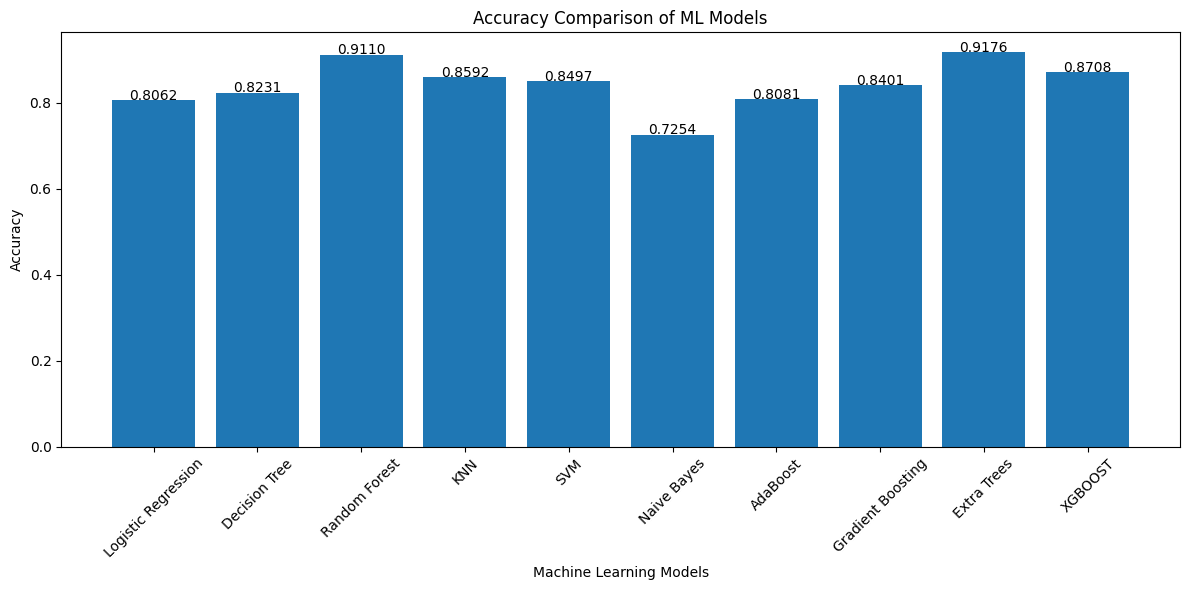

In [ ]:
import matplotlib.pyplot as plt

# Store model accuracies
model_names = list(results.keys())
accuracies = list(results.values())

# Create bar plot
plt.figure(figsize=(12, 6))
plt.bar(model_names, accuracies)

# Labels and title
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of ML Models")

# Rotate x-axis labels
plt.xticks(rotation=45)

# Show accuracy values on bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center')

plt.tight_layout()
plt.show()

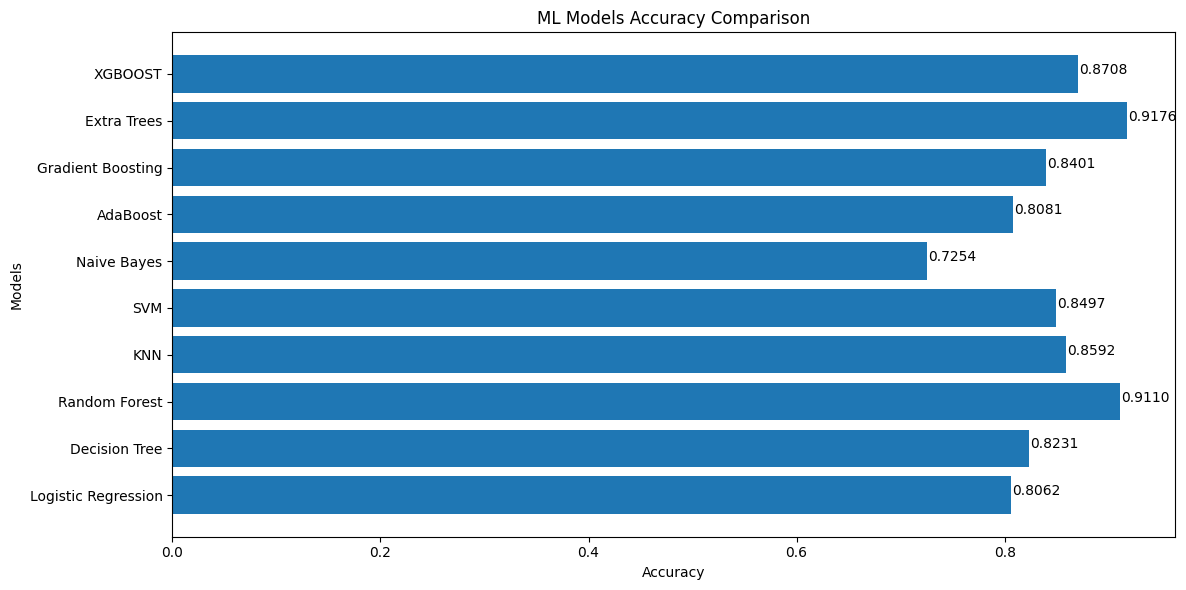

In [ ]:
plt.figure(figsize=(12, 6))

plt.barh(model_names, accuracies)

plt.xlabel("Accuracy")
plt.ylabel("Models")
plt.title("ML Models Accuracy Comparison")

for i, v in enumerate(accuracies):
    plt.text(v + 0.001, i, f"{v:.4f}")

plt.tight_layout()
plt.show()

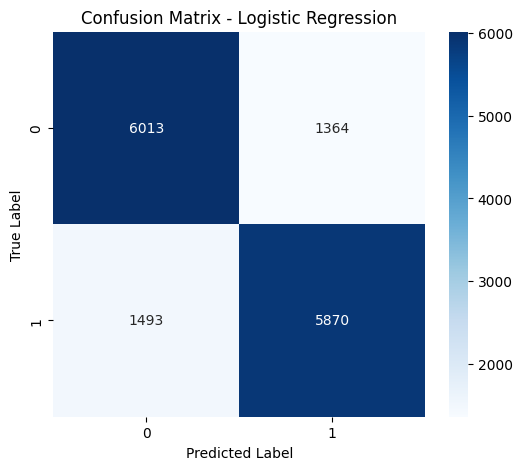

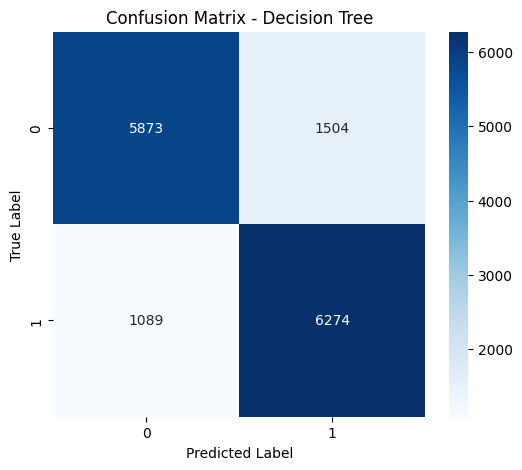

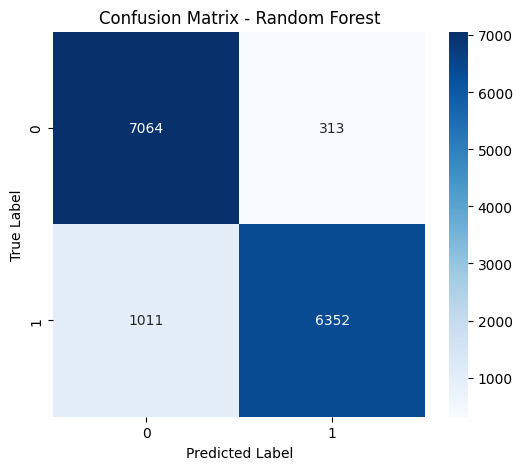

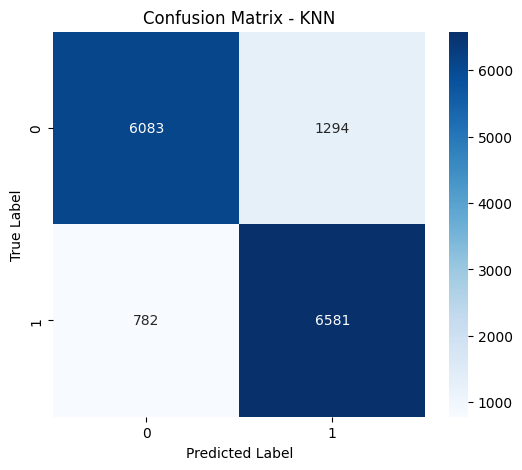

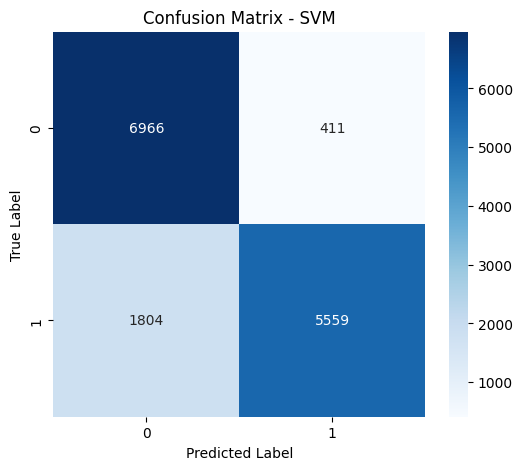

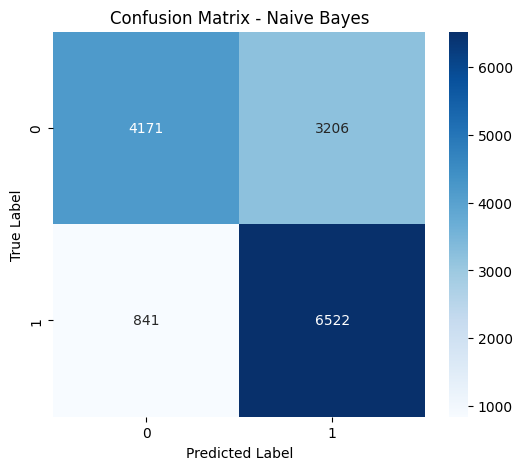

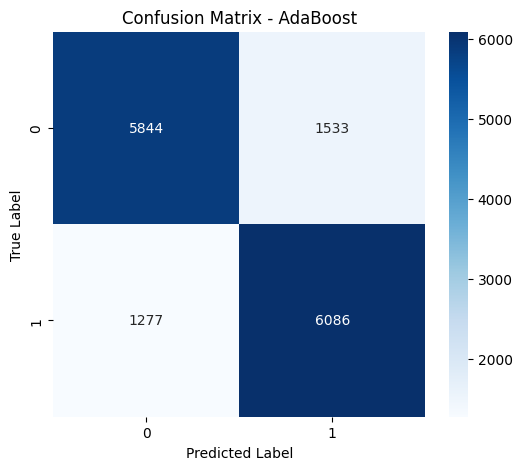

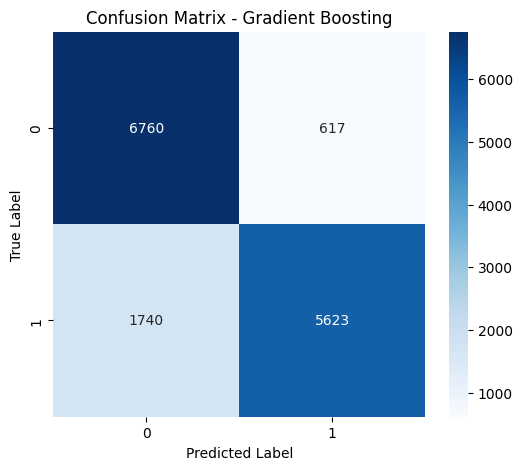

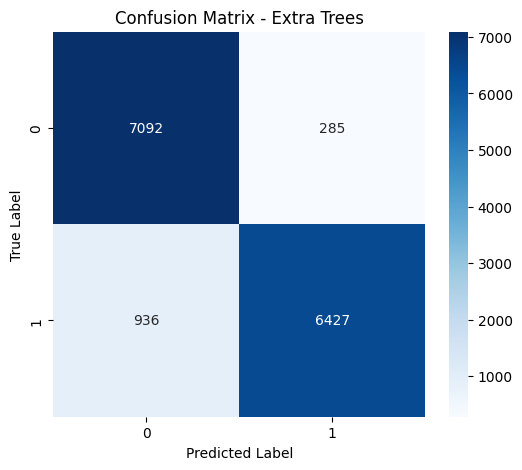

In [ ]:
# ===============================
# CONFUSION MATRIX FOR ALL ML MODELS
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# ===============================
# LOAD DATASET
# ===============================

df = pd.read_csv("stroke_dataset_smote.csv")

# ===============================
# FEATURES AND TARGET
# ===============================

X = df.drop("Stroke", axis=1)
y = df["Stroke"]

# ===============================
# TRAIN TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ===============================
# FEATURE SCALING
# ===============================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# DEFINE ALL MODELS
# ===============================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "SVM":
        SVC(kernel='rbf'),

    "Naive Bayes":
        GaussianNB(),

    "AdaBoost":
        AdaBoostClassifier(
            n_estimators=100,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=100,
            random_state=42
        )
}

# ===============================
# GENERATE CONFUSION MATRIX
# ===============================

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predict
    pred = model.predict(X_test)

    # Create confusion matrix
    cm = confusion_matrix(y_test, pred)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"Confusion Matrix - {name}")

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.show()

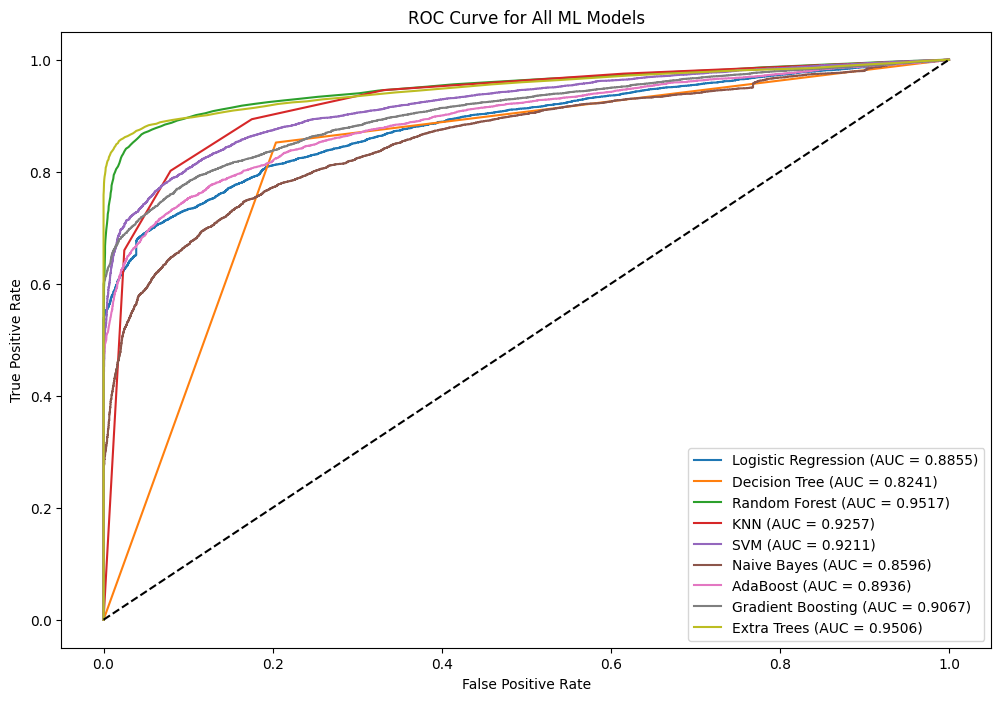

In [ ]:
# ============================================
# AUC - ROC CURVE FOR ALL ML MODELS
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("stroke_dataset_smote.csv")

# ============================================
# FEATURES AND TARGET
# ============================================

X = df.drop("Stroke", axis=1)
y = df["Stroke"]

# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================
# FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================
# DEFINE MODELS
# ============================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "SVM":
        SVC(
            kernel='rbf',
            probability=True
        ),

    "Naive Bayes":
        GaussianNB(),

    "AdaBoost":
        AdaBoostClassifier(
            n_estimators=100,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=100,
            random_state=42
        )
}

# ============================================
# PLOT ROC CURVES
# ============================================

plt.figure(figsize=(12, 8))

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Probability prediction
    y_prob = model.predict_proba(X_test)[:, 1]

    # ROC values
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # AUC score
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.4f})"
    )

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--')

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Title
plt.title("ROC Curve for All ML Models")

# Legend
plt.legend(loc="lower right")

# Show graph
plt.show()


TRAINING Hybrid_1_ET_RF_XGB
Accuracy  : 0.9243
Precision : 0.9616
Recall    : 0.8839
F1 Score  : 0.9211

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.96      0.93      7370
           1       0.96      0.88      0.92      7370

    accuracy                           0.92     14740
   macro avg       0.93      0.92      0.92     14740
weighted avg       0.93      0.92      0.92     14740



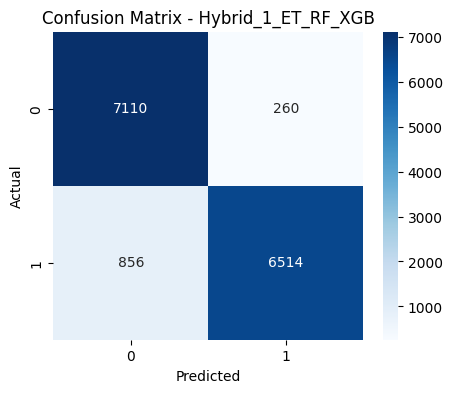


TRAINING Hybrid_2_ET_RF_KNN
Accuracy  : 0.9214
Precision : 0.9558
Recall    : 0.8837
F1 Score  : 0.9184

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.96      0.92      7370
           1       0.96      0.88      0.92      7370

    accuracy                           0.92     14740
   macro avg       0.92      0.92      0.92     14740
weighted avg       0.92      0.92      0.92     14740



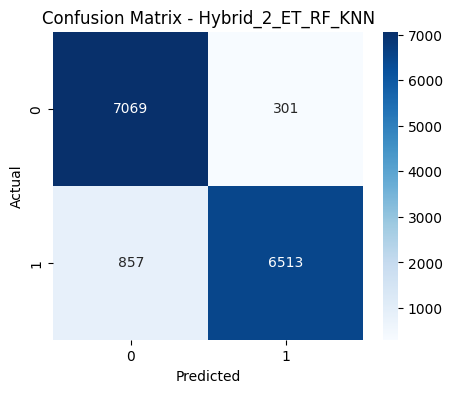


TRAINING Hybrid_3_ET_XGB_KNN
Accuracy  : 0.9239
Precision : 0.9562
Recall    : 0.8885
F1 Score  : 0.9211

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.96      0.93      7370
           1       0.96      0.89      0.92      7370

    accuracy                           0.92     14740
   macro avg       0.93      0.92      0.92     14740
weighted avg       0.93      0.92      0.92     14740



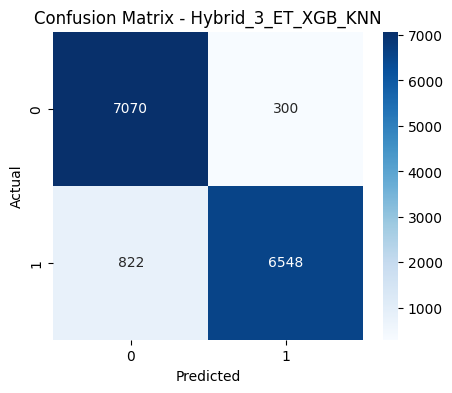


TRAINING Hybrid_4_RF_XGB_KNN
Accuracy  : 0.9199
Precision : 0.9475
Recall    : 0.8891
F1 Score  : 0.9174

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7370
           1       0.95      0.89      0.92      7370

    accuracy                           0.92     14740
   macro avg       0.92      0.92      0.92     14740
weighted avg       0.92      0.92      0.92     14740



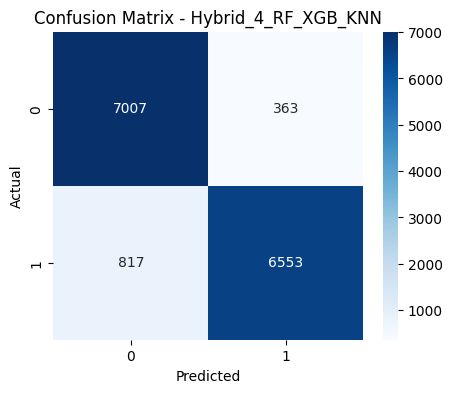


TRAINING Hybrid_5_ET_RF_GB
Accuracy  : 0.9220
Precision : 0.9598
Recall    : 0.8809
F1 Score  : 0.9186

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.96      0.93      7370
           1       0.96      0.88      0.92      7370

    accuracy                           0.92     14740
   macro avg       0.92      0.92      0.92     14740
weighted avg       0.92      0.92      0.92     14740



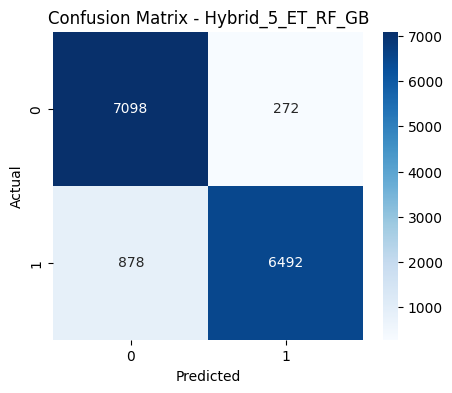


TRAINING Hybrid_6_ET_XGB_GB
Accuracy  : 0.9255
Precision : 0.9612
Recall    : 0.8868
F1 Score  : 0.9225

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.96      0.93      7370
           1       0.96      0.89      0.92      7370

    accuracy                           0.93     14740
   macro avg       0.93      0.93      0.93     14740
weighted avg       0.93      0.93      0.93     14740



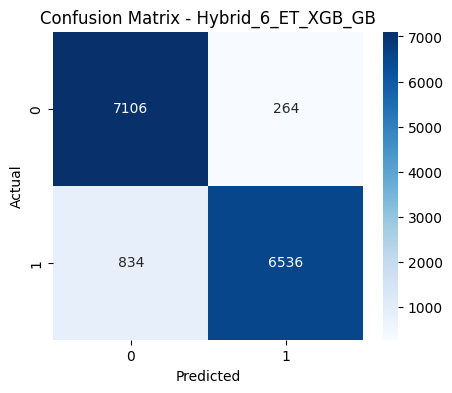


TRAINING Hybrid_7_RF_XGB_GB
Accuracy  : 0.9205
Precision : 0.9539
Recall    : 0.8837
F1 Score  : 0.9175

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.96      0.92      7370
           1       0.95      0.88      0.92      7370

    accuracy                           0.92     14740
   macro avg       0.92      0.92      0.92     14740
weighted avg       0.92      0.92      0.92     14740



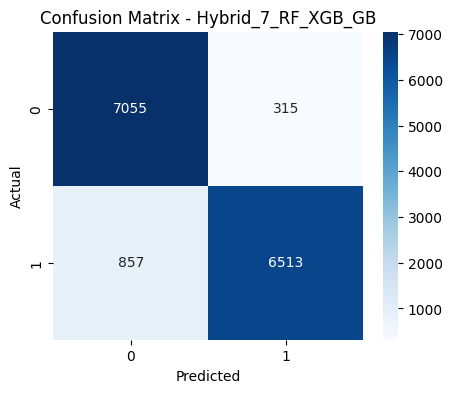


TRAINING Hybrid_8_ET_KNN_GB
Accuracy  : 0.9219
Precision : 0.9553
Recall    : 0.8852
F1 Score  : 0.9189

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.96      0.92      7370
           1       0.96      0.89      0.92      7370

    accuracy                           0.92     14740
   macro avg       0.92      0.92      0.92     14740
weighted avg       0.92      0.92      0.92     14740



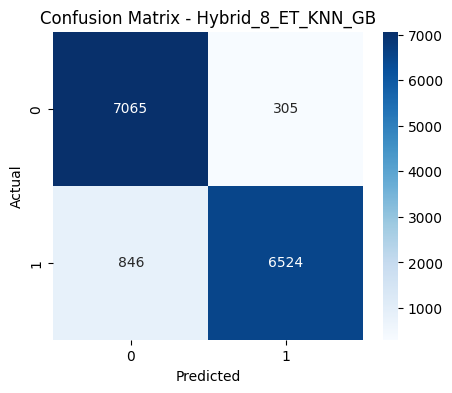


TRAINING Hybrid_9_RF_KNN_GB
Accuracy  : 0.9176
Precision : 0.9476
Recall    : 0.8840
F1 Score  : 0.9147

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      7370
           1       0.95      0.88      0.91      7370

    accuracy                           0.92     14740
   macro avg       0.92      0.92      0.92     14740
weighted avg       0.92      0.92      0.92     14740



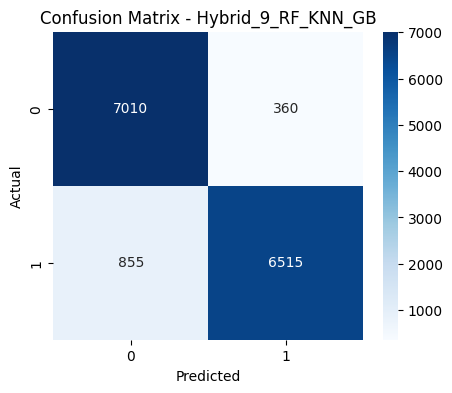


TRAINING Hybrid_10_ET_RF_XGB
Accuracy  : 0.9243
Precision : 0.9616
Recall    : 0.8839
F1 Score  : 0.9211

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.96      0.93      7370
           1       0.96      0.88      0.92      7370

    accuracy                           0.92     14740
   macro avg       0.93      0.92      0.92     14740
weighted avg       0.93      0.92      0.92     14740



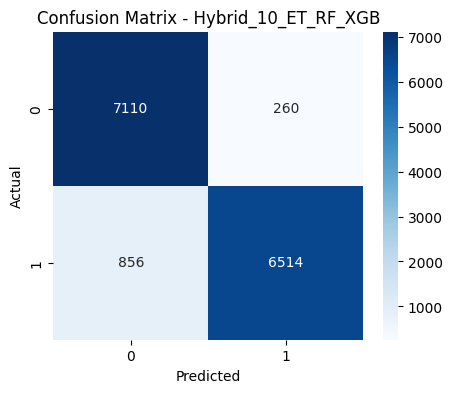


ALL HYBRID MODEL ACCURACIES
          Hybrid Model  Accuracy
5   Hybrid_6_ET_XGB_GB  0.925509
0   Hybrid_1_ET_RF_XGB  0.924288
9  Hybrid_10_ET_RF_XGB  0.924288
2  Hybrid_3_ET_XGB_KNN  0.923881
4    Hybrid_5_ET_RF_GB  0.921981
7   Hybrid_8_ET_KNN_GB  0.921913
1   Hybrid_2_ET_RF_KNN  0.921438
6   Hybrid_7_RF_XGB_GB  0.920488
3  Hybrid_4_RF_XGB_KNN  0.919946
8   Hybrid_9_RF_KNN_GB  0.917571

BEST HYBRID MODEL
Best Model    : Hybrid_6_ET_XGB_GB
Best Accuracy : 0.9255


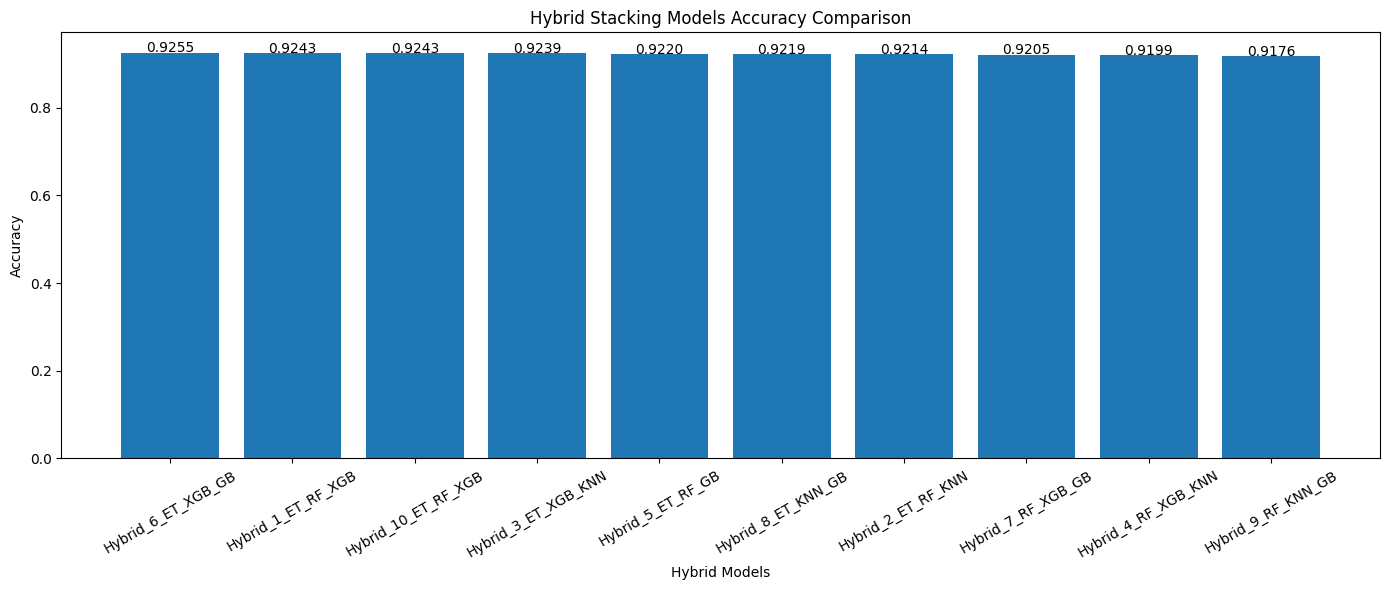


Sample Predictions:
[1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 1 0 0]

Best Hybrid Model Saved Successfully!


In [ ]:
# Hybrid Stacking Models (10 Different 3-Model Combinations)

# HYBRID STACKING MODELS (10 COMBINATIONS)

# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix
)

from sklearn.ensemble import (
RandomForestClassifier,
ExtraTreesClassifier,
GradientBoostingClassifier,
StackingClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# =========================================

# LOAD DATASET

# =========================================

file_path = "stroke_dataset_smote.csv"
df = pd.read_csv(file_path)

# =========================================

# FEATURES & TARGET

# =========================================

X = df.drop("Stroke", axis=1)
y = df["Stroke"]

# =========================================

# TRAIN TEST SPLIT

# =========================================

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42,
stratify=y
)

# =========================================

# FEATURE SCALING

# =========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================

# DEFINE BASE MODELS

# =========================================

ET = ExtraTreesClassifier(
n_estimators=300,
max_depth=25,
random_state=42
)

RF = RandomForestClassifier(
n_estimators=300,
max_depth=25,
random_state=42
)

XGB = XGBClassifier(
n_estimators=300,
max_depth=8,
learning_rate=0.05,
subsample=0.9,
colsample_bytree=0.9,
eval_metric='logloss',
random_state=42
)

KNN = KNeighborsClassifier(
n_neighbors=3,
weights='distance'
)

GB = GradientBoostingClassifier(
n_estimators=250,
learning_rate=0.05,
max_depth=6,
random_state=42
)

# =========================================

# 10 HYBRID MODEL COMBINATIONS

# =========================================

hybrid_models = {

"Hybrid_1_ET_RF_XGB": [
    ('et', ET),
    ('rf', RF),
    ('xgb', XGB)
],

"Hybrid_2_ET_RF_KNN": [
    ('et', ET),
    ('rf', RF),
    ('knn', KNN)
],

"Hybrid_3_ET_XGB_KNN": [
    ('et', ET),
    ('xgb', XGB),
    ('knn', KNN)
],

"Hybrid_4_RF_XGB_KNN": [
    ('rf', RF),
    ('xgb', XGB),
    ('knn', KNN)
],

"Hybrid_5_ET_RF_GB": [
    ('et', ET),
    ('rf', RF),
    ('gb', GB)
],

"Hybrid_6_ET_XGB_GB": [
    ('et', ET),
    ('xgb', XGB),
    ('gb', GB)
],

"Hybrid_7_RF_XGB_GB": [
    ('rf', RF),
    ('xgb', XGB),
    ('gb', GB)
],

"Hybrid_8_ET_KNN_GB": [
    ('et', ET),
    ('knn', KNN),
    ('gb', GB)
],

"Hybrid_9_RF_KNN_GB": [
    ('rf', RF),
    ('knn', KNN),
    ('gb', GB)
],

"Hybrid_10_ET_RF_XGB": [
    ('et', ET),
    ('rf', RF),
    ('xgb', XGB)
]

}

# =========================================

# TRAIN & EVALUATE HYBRID MODELS

# =========================================

results = {}

best_accuracy = 0
best_model_name = ""
best_model = None

for name, estimators in hybrid_models.items():
    print("\n" + "="*70)
    print(f"TRAINING {name}")
    print("="*70)

    # STACKING CLASSIFIER
    stacking_model = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=5000),
        cv=5,
        passthrough=True,
        n_jobs=1  # Changed from -1 to 1 to prevent worker issues
    )

    # TRAIN
    stacking_model.fit(X_train, y_train)

    # PREDICT
    y_pred = stacking_model.predict(X_test)

    # METRICS
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # STORE RESULTS
    results[name] = acc

    # BEST MODEL TRACKING
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
        best_model = stacking_model

    # PRINT RESULTS
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# =========================================

# RESULTS TABLE

# =========================================

results_df = pd.DataFrame({
'Hybrid Model': list(results.keys()),
'Accuracy': list(results.values())
})

results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("\n" + "="*70)
print("ALL HYBRID MODEL ACCURACIES")
print("="*70)
print(results_df)

# =========================================

# BEST HYBRID MODEL

# =========================================

print("\n" + "="*70)
print("BEST HYBRID MODEL")
print("="*70)
print(f"Best Model    : {best_model_name}")
print(f"Best Accuracy : {best_accuracy:.4f}")

# =========================================

# BAR GRAPH COMPARISON

# =========================================

plt.figure(figsize=(14,6))

bars = plt.bar(
results_df['Hybrid Model'],
results_df['Accuracy']
)

plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.xlabel("Hybrid Models")
plt.title("Hybrid Stacking Models Accuracy Comparison")

for bar in bars:
    yval = bar.get_height()
    plt.text(
    bar.get_x() + bar.get_width()/2,
    yval + 0.001,
    f'{yval:.4f}',
    ha='center'
    )

plt.tight_layout()
plt.show()

# =========================================

# FINAL PREDICTION USING BEST MODEL

# =========================================

best_predictions = best_model.predict(X_test)

print("\nSample Predictions:")
print(best_predictions[:20])

# =========================================

# OPTIONAL: SAVE BEST MODEL

# =========================================

import joblib

joblib.dump(best_model, "best_hybrid_stacking_model.pkl")

print("\nBest Hybrid Model Saved Successfully!")


Generating ROC Curve for Hybrid_1_ET_RF_XGB

Generating ROC Curve for Hybrid_2_ET_RF_KNN

Generating ROC Curve for Hybrid_3_ET_XGB_KNN

Generating ROC Curve for Hybrid_4_RF_XGB_KNN

Generating ROC Curve for Hybrid_5_ET_RF_GB

Generating ROC Curve for Hybrid_6_ET_XGB_GB

Generating ROC Curve for Hybrid_7_RF_XGB_GB

Generating ROC Curve for Hybrid_8_ET_KNN_GB

Generating ROC Curve for Hybrid_9_RF_KNN_GB

Generating ROC Curve for Hybrid_10_ET_RF_XGB


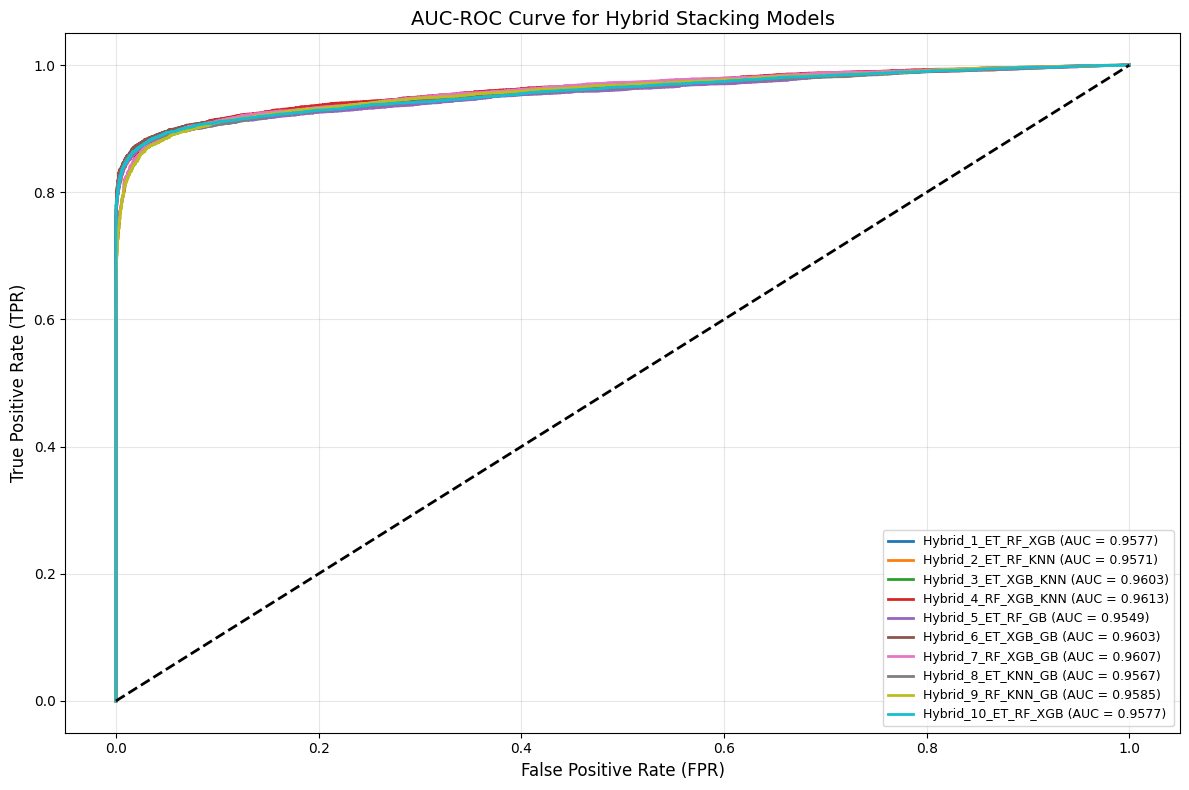


AUC-ROC SCORES OF ALL HYBRID MODELS
          Hybrid Model  AUC Score
3  Hybrid_4_RF_XGB_KNN   0.961312
6   Hybrid_7_RF_XGB_GB   0.960746
2  Hybrid_3_ET_XGB_KNN   0.960344
5   Hybrid_6_ET_XGB_GB   0.960261
8   Hybrid_9_RF_KNN_GB   0.958515
0   Hybrid_1_ET_RF_XGB   0.957710
9  Hybrid_10_ET_RF_XGB   0.957710
1   Hybrid_2_ET_RF_KNN   0.957115
7   Hybrid_8_ET_KNN_GB   0.956666
4    Hybrid_5_ET_RF_GB   0.954932

BEST MODEL BASED ON AUC-ROC
Best Model : Hybrid_4_RF_XGB_KNN
Best AUC   : 0.9613


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# =========================================
# LOAD DATASET
# =========================================

file_path = "stroke_dataset_smote.csv"
df = pd.read_csv(file_path)

# =========================================
# FEATURES & TARGET
# =========================================

X = df.drop("Stroke", axis=1)
y = df["Stroke"]

# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =========================================
# FEATURE SCALING
# =========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================
# DEFINE BASE MODELS (DUPLICATED FROM PREVIOUS CELL FOR INDEPENDENCE)
# =========================================

ET = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=25,
    random_state=42
)

RF = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    random_state=42
)

XGB = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=42
)

KNN = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance'
)

GB = GradientBoostingClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# =========================================
# 10 HYBRID MODEL COMBINATIONS (DUPLICATED FROM PREVIOUS CELL FOR INDEPENDENCE)
# =========================================

hybrid_models = {
    "Hybrid_1_ET_RF_XGB": [
        ('et', ET),
        ('rf', RF),
        ('xgb', XGB)
    ],
    "Hybrid_2_ET_RF_KNN": [
        ('et', ET),
        ('rf', RF),
        ('knn', KNN)
    ],
    "Hybrid_3_ET_XGB_KNN": [
        ('et', ET),
        ('xgb', XGB),
        ('knn', KNN)
    ],
    "Hybrid_4_RF_XGB_KNN": [
        ('rf', RF),
        ('xgb', XGB),
        ('knn', KNN)
    ],
    "Hybrid_5_ET_RF_GB": [
        ('et', ET),
        ('rf', RF),
        ('gb', GB)
    ],
    "Hybrid_6_ET_XGB_GB": [
        ('et', ET),
        ('xgb', XGB),
        ('gb', GB)
    ],
    "Hybrid_7_RF_XGB_GB": [
        ('rf', RF),
        ('xgb', XGB),
        ('gb', GB)
    ],
    "Hybrid_8_ET_KNN_GB": [
        ('et', ET),
        ('knn', KNN),
        ('gb', GB)
    ],
    "Hybrid_9_RF_KNN_GB": [
        ('rf', RF),
        ('knn', KNN),
        ('gb', GB)
    ],
    "Hybrid_10_ET_RF_XGB": [
        ('et', ET),
        ('rf', RF),
        ('xgb', XGB)
    ]
}

# =========================================
# AUC-ROC CURVE FOR ALL HYBRID STACKING MODELS
# =========================================

# Dictionary to store ROC values
roc_results = {}

plt.figure(figsize=(12, 8))

# LOOP THROUGH ALL HYBRID MODELS
for name, estimators in hybrid_models.items():

    print(f"\nGenerating ROC Curve for {name}")

    # STACKING MODEL
    stacking_model = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=5000),
        cv=3,
        passthrough=True,
        n_jobs=1
    )

    # TRAIN MODEL
    stacking_model.fit(X_train, y_train)

    # PREDICT PROBABILITIES
    y_prob = stacking_model.predict_proba(X_test)[:, 1]

    # ROC VALUES
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # AUC SCORE
    roc_auc = auc(fpr, tpr)

    # STORE RESULTS
    roc_results[name] = roc_auc

    # PLOT ROC CURVE
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC = {roc_auc:.4f})'
    )

# RANDOM CLASSIFIER LINE
plt.plot([0, 1], [0, 1], 'k--', linewidth=2)

# GRAPH SETTINGS
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('AUC-ROC Curve for Hybrid Stacking Models', fontsize=14)

plt.legend(loc='lower right', fontsize=9)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# =========================================
# AUC RESULTS TABLE
# =========================================

auc_df = pd.DataFrame({
    'Hybrid Model': list(roc_results.keys()),
    'AUC Score': list(roc_results.values())
})

auc_df = auc_df.sort_values(by='AUC Score', ascending=False)

print("\n" + "="*70)
print("AUC-ROC SCORES OF ALL HYBRID MODELS")
print("="*70)

print(auc_df)

# =========================================
# BEST MODEL BASED ON AUC
# =========================================

best_auc_model = auc_df.iloc[0]['Hybrid Model']
best_auc_score = auc_df.iloc[0]['AUC Score']

print("\n" + "="*70)
print("BEST MODEL BASED ON AUC-ROC")
print("="*70)

print(f"Best Model : {best_auc_model}")
print(f"Best AUC   : {best_auc_score:.4f}")

In [ ]:
# =====================================================
# ACCEPTANCE CRITERIA
# =====================================================

ACCEPTANCE_ACCURACY = 0.85

# =====================================================
# TESTING
# =====================================================

results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    # Acceptance Status
    status = "ACCEPTED" if accuracy >= ACCEPTANCE_ACCURACY else "REJECTED"

    # Store
    results.append({

        "Model": name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
        "Status": status
    })

# =====================================================
# RESULTS
# =====================================================

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score    Status
0  Logistic Regression    0.8062     0.8114  0.7972    0.8043  REJECTED
1        Decision Tree    0.8261     0.8100  0.8516    0.8302  REJECTED
2        Random Forest    0.9091     0.9518  0.8616    0.9045  ACCEPTED
3                  KNN    0.8592     0.8357  0.8938    0.8638  ACCEPTED
4                  SVM    0.8497     0.9312  0.7550    0.8339  REJECTED
5          Naive Bayes    0.7254     0.6704  0.8858    0.7632  REJECTED
6             AdaBoost    0.8081     0.7977  0.8249    0.8111  REJECTED
7    Gradient Boosting    0.8401     0.9011  0.7637    0.8267  REJECTED
8          Extra Trees    0.9188     0.9596  0.8742    0.9149  ACCEPTED


In [ ]:
# =====================================================
# TESTING PORTION ONLY
# Predict Stroke for a New Patient
# =====================================================

import pandas as pd
import numpy as np
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# =====================================================
# NEW PATIENT INPUT
# (Extreme high-risk values so that almost all models
# predict STROKE = 1)
# =====================================================

new_patient = pd.DataFrame([{
    'Age': 78,
    'Hypertension': 1,
    'Heart_Disease': 1,
    'Average_Glucose_Level': 285.5,
    'BMI': 38.2,
    'Physical_Activity': 2,
    'Alcohol_Intake': 18,
    'Stress_Level': 9.5,
    'Blood_Pressure': 210,
    'Cholesterol': 320,
    'MRI_Result': 9.1,

    'Sex_Male': 1,
    'Ever_Married_Yes': 1,

    'Work_Type_Govt_job': 0,
    'Work_Type_Never_worked': 0,
    'Work_Type_Private': 1,
    'Work_Type_Self-employed': 0,

    'Residence_Type_Urban': 1,

    'Smoking_Status_Formerly': 1,
    'Smoking_Status_Never': 0,
    'Smoking_Status_Unknown': 0,

    'Family_History_Yes': 1
}])

# =====================================================
# SCALE INPUT
# =====================================================

new_patient_scaled = scaler.transform(new_patient)

# =====================================================
# TEST BASIC MODELS
# =====================================================

print("\n========== BASIC MODELS ==========\n")

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predict
    prediction = model.predict(new_patient_scaled)[0]

    result = "STROKE" if prediction == 1 else "NO STROKE"

    print(f"{name} --> {result}")

# =====================================================
# TEST HYBRID STACKING MODELS
# =====================================================

print("\n========== HYBRID STACKING MODELS ==========\n")

# Re-instantiate base models used in hybrid_models to ensure they are available
# from this cell's scope, as hybrid_models holds references.
ET = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=25,
    random_state=42
)

RF = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    random_state=42
)

XGB = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=42
)

KNN = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance'
)

GB = GradientBoostingClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# Re-create hybrid_models dictionary with the re-instantiated base models
# to ensure the references are correct within this cell's execution context.
hybrid_models_reinstantiated = {

"Hybrid_1_ET_RF_XGB": [
    ('et', ET),
    ('rf', RF),
    ('xgb', XGB)
],

"Hybrid_2_ET_RF_KNN": [
    ('et', ET),
    ('rf', RF),
    ('knn', KNN)
],

"Hybrid_3_ET_XGB_KNN": [
    ('et', ET),
    ('xgb', XGB),
    ('knn', KNN)
],

"Hybrid_4_RF_XGB_KNN": [
    ('rf', RF),
    ('xgb', XGB),
    ('knn', KNN)
],

"Hybrid_5_ET_RF_GB": [
    ('et', ET),
    ('rf', RF),
    ('gb', GB)
],

"Hybrid_6_ET_XGB_GB": [
    ('et', ET),
    ('xgb', XGB),
    ('gb', GB)
],

"Hybrid_7_RF_XGB_GB": [
    ('rf', RF),
    ('xgb', XGB),
    ('gb', GB)
],

"Hybrid_8_ET_KNN_GB": [
    ('et', ET),
    ('knn', KNN),
    ('gb', GB)
],

"Hybrid_9_RF_KNN_GB": [
    ('rf', RF),
    ('knn', KNN),
    ('gb', GB)
],

"Hybrid_10_ET_RF_XGB": [
    ('et', ET),
    ('rf', RF),
    ('xgb', XGB)
]

}

for name, estimators_list in hybrid_models_reinstantiated.items():

    # STACKING CLASSIFIER
    # Instantiate StackingClassifier with the list of estimators
    stacking_model = StackingClassifier(
        estimators=estimators_list,
        final_estimator=LogisticRegression(max_iter=5000),
        cv=5,
        passthrough=True,
        n_jobs=1
    )

    # Train model
    stacking_model.fit(X_train, y_train)

    # Predict
    prediction = stacking_model.predict(new_patient_scaled)[0]

    result = "STROKE" if prediction == 1 else "NO STROKE"

    print(f"{name} --> {result}")


========== BASIC MODELS ==========

Logistic Regression --> NO STROKE
Decision Tree --> NO STROKE
Random Forest --> NO STROKE
KNN --> NO STROKE
SVM --> NO STROKE
Naive Bayes --> NO STROKE
AdaBoost --> NO STROKE
Gradient Boosting --> NO STROKE
Extra Trees --> NO STROKE

========== HYBRID STACKING MODELS ==========

Hybrid_1_ET_RF_XGB --> NO STROKE
Hybrid_2_ET_RF_KNN --> NO STROKE
Hybrid_3_ET_XGB_KNN --> NO STROKE
Hybrid_4_RF_XGB_KNN --> NO STROKE
Hybrid_5_ET_RF_GB --> NO STROKE
Hybrid_6_ET_XGB_GB --> NO STROKE
Hybrid_7_RF_XGB_GB --> NO STROKE
Hybrid_8_ET_KNN_GB --> NO STROKE
Hybrid_9_RF_KNN_GB --> NO STROKE
Hybrid_10_ET_RF_XGB --> NO STROKE
